# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
    
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset

   - Number of samples

   - What the text represents (reviews, tweets, comments, etc.)

   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

   

---

## 📝 Your Project Definition

**Business Problem:**

*Is it possible to determine if the movie review is positive or negative based upon its text length?*

---

**Dataset Description:**

*[Write your answer here]*

- **Dataset name**: IMDBdataset.csv
- **Source**: Kaggle
- **Number of samples**: 50,000
- **Text type**: Movie reviews
- **Sentiment labels**: positive/negative

---

**Importance and Real-World Applications:**

*Streaming platforms - could use the results to suggest movies with similar sentiment*

*Studios and producers could identify viewers reactions and shape marketing strategies for home video releases.*

*Movie Critics - they can get statistical data about the movie audience opinions and sentiment without having to read the reviews.*



---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load your dataset
# Example: df = pd.read_csv('your_dataset.csv')
# For large datasets, consider using nrows parameter: pd.read_csv('file.csv', nrows=10000)



import pandas as pd

# YOUR CODE HERE
df = pd.read_csv("/content/drive/My Drive/SentimentProject/IMDBdataset.csv")  # Replace with your data loading code

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head()



Dataset shape: (50000, 2)

Column names: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# 🎯 IMPORTANT: If working with limited resources, sample your data here
# Uncomment and modify as needed:
# I think my computer can handle this so I am going to leave this as is and come back if it doesn't work

# df_sample = df.sample(n=5000, random_state=42)
# print(f"Working with {len(df_sample)} samples")
# df = df_sample  # Use the sample for the rest of the project

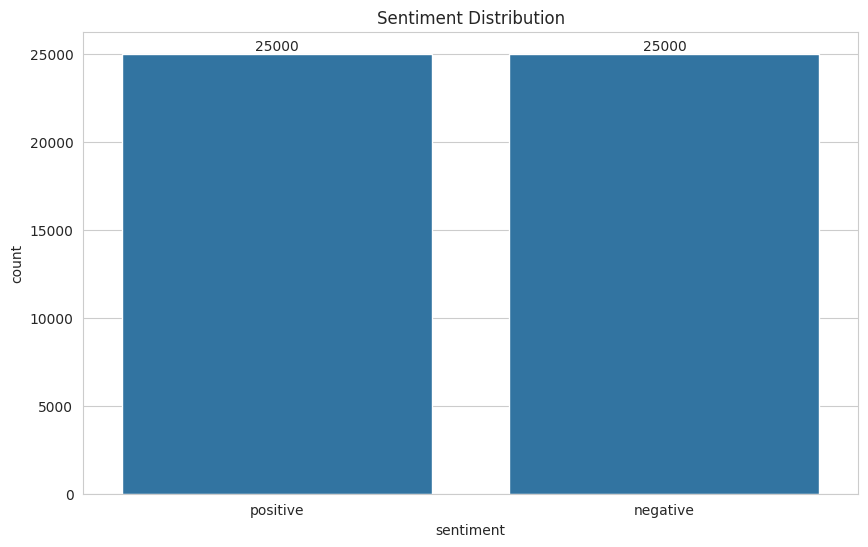

In [ ]:
# Analyze sentiment distribution
# YOUR CODE HERE
df['sentiment'].value_counts()


# Hint: Use df['sentiment_column'].value_counts()
# Create a bar plot to visualize the distribution
ax = sns.countplot(x='sentiment', data=df)

# Add totals to top of each column bar
for p in ax.patches:
    height = int(p.get_height()) # give me whole numbers only by converting to integer
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')

plt.title("Sentiment Distribution")
plt.show()


### 📊 Interpretation: Class Balance

*Write your observations here:*
- Are the classes balanced or imbalanced?

Balanced and split evenly. Half are positive and half are negative. This balance is ideal because it prevents bias towards one sentiment.

- If imbalanced, how might this affect your model?

If I am trying to determine if sentiment text length can suggest the sentiment itself, then the length could skew the results to favor the majority sentiment to the detriment of the minority sentiment.  Having equal representative numbers can provide a better comparison and better predictive performance.

- What could you do to address imbalance?

I could curate the data by over sampling the minority to add more to the data set which then risks overfitting since the data is more of itself or use SMOTE to create new synthetic samples for the minority class by interpolation between existing samples (I used to do this for crude oil pricing when trying to calculate the curve. I digress.)

I could also undersample the majority class and pare away samples until the classes are balanced. It is literally tossing out actual data that could be useful.

I could also go full on nerd and start weight ranking classes but I am going to keep it simple because I can't remember exactly how I used to do that. I will save that for the next class.

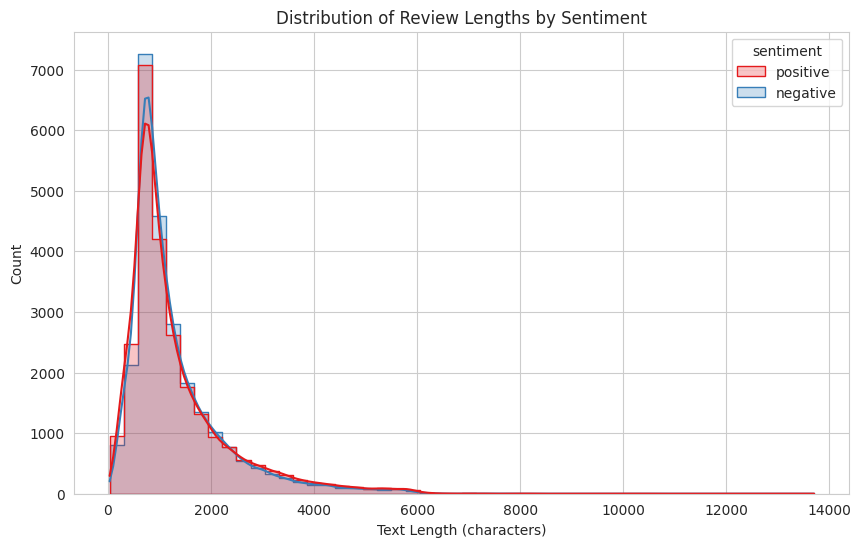

In [ ]:
# Analyze text length distribution
# YOUR CODE HERE

# Ensure all reviews are strings
df['review'] = df['review'].astype(str)

# Hint: Create a new column for text length
# Create a new column for text length
df['text_length'] = df['review'].str.len()




# Plot histogram of text lengths, separated by sentiment
sns.histplot(data=df, x='text_length', hue='sentiment', bins=50, kde=True, element="step", palette="Set1") #Trying to find something that I can see easily)

plt.title("Distribution of Review Lengths by Sentiment")
plt.xlabel("Text Length (characters)")
plt.ylabel("Count")
plt.show()



# df['text_length'] = df['text_column'].str.len()

# Compare lengths across different sentiments

This graph is fairly useless to me. I need other graphs to give me more slicing and dicing. It is useful but it just makes me ask so many more questions.  I want more nitty gritty detail. I need it broken into smaller sets.

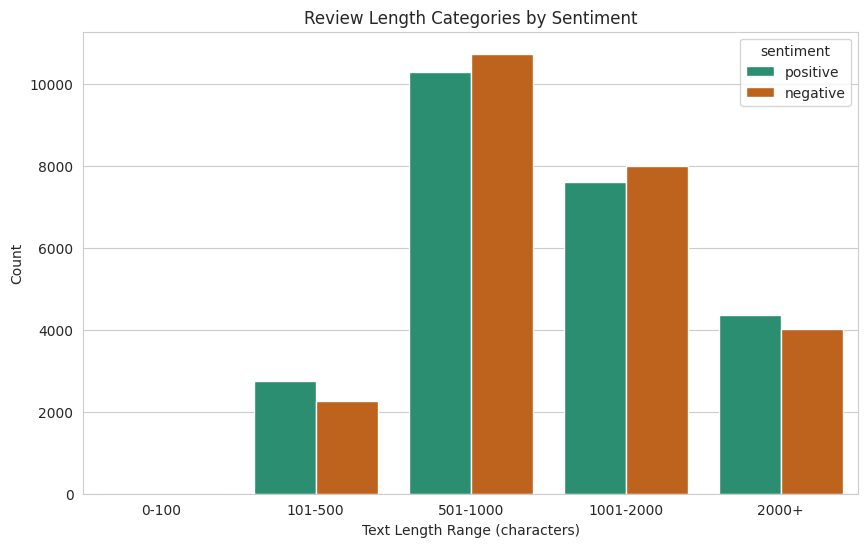

In [ ]:
# Define bins
bins = [0, 100, 500, 1000, 2000, df['text_length'].max()]
labels = ['0-100', '101-500', '501-1000', '1001-2000', '2000+']

df['length_bin'] = pd.cut(df['text_length'], bins=bins, labels=labels)

sns.countplot(x='length_bin', hue='sentiment', data=df, palette="Dark2")
plt.title("Review Length Categories by Sentiment")
plt.xlabel("Text Length Range (characters)")
plt.ylabel("Count")
plt.show()


I want to look at this with the averages above the bars and also bin them.

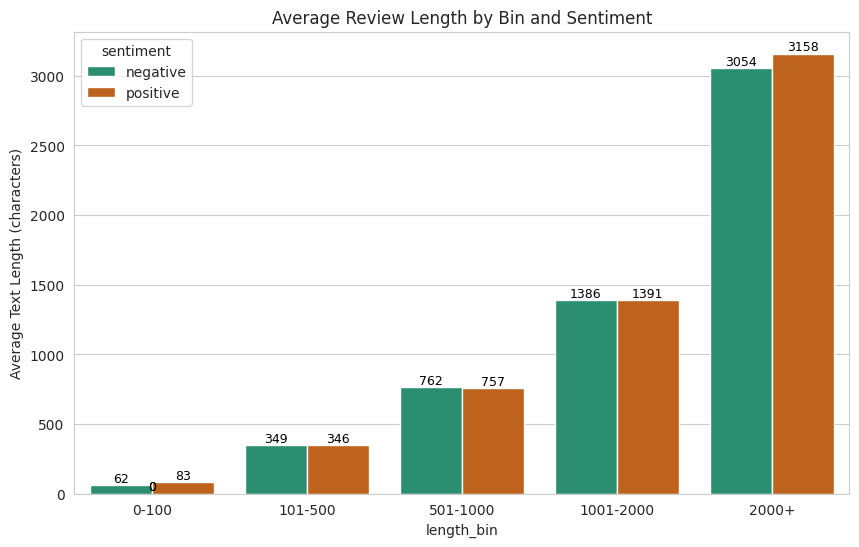

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define bins
bins = [0, 100, 500, 1000, 2000, df['text_length'].max()]
labels = ['0-100', '101-500', '501-1000', '1001-2000', '2000+']

df['length_bin'] = pd.cut(df['text_length'], bins=bins, labels=labels)

# Compute average text length per bin/sentiment
avg_lengths = df.groupby(['length_bin','sentiment'])['text_length'].mean().round(0).reset_index()

# Plot bar chart of averages
ax = sns.barplot(x='length_bin', y='text_length', hue='sentiment', data=avg_lengths, palette="Dark2")

# Annotate averages above bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=9, color='black')

plt.title("Average Review Length by Bin and Sentiment")
plt.ylabel("Average Text Length (characters)")
plt.show()





I lost samples due to binning. 😱  So, now I had to have help writing code to use safe binning that keeps all the data.  

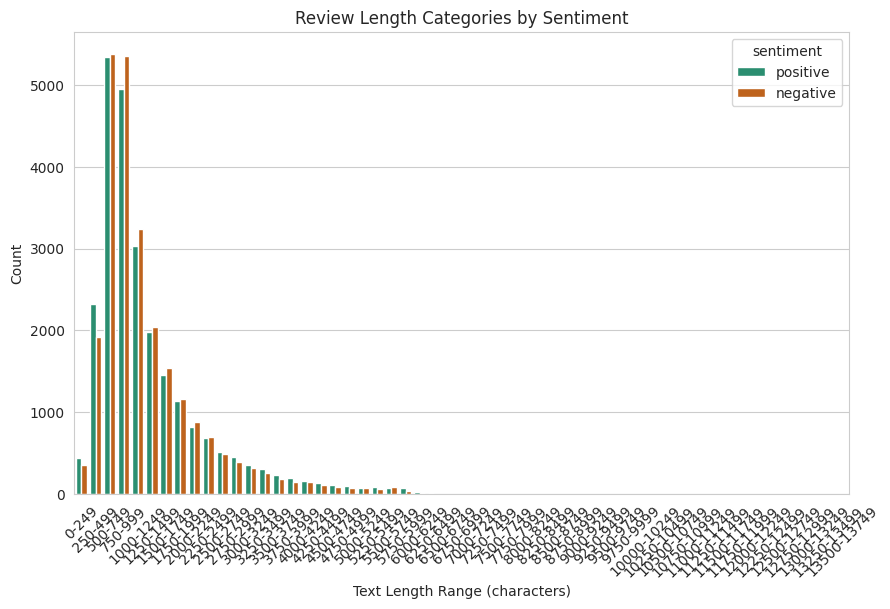

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def safe_binning(df, col='text_length', step=250):
    """
    Automatically creates bins from 0 up to the max length in the dataset.
    Ensures no samples are dropped.

    Parameters:
    df  : DataFrame containing the column
    col : Column name to bin (default 'text_length')
    step: Bin width (default 500 characters)
    """
    max_len = df[col].max()

    # Create bins from 0 to max length, with step size
    bins = np.arange(0, max_len + step, step)
    labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]

    df['length_bin'] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)
    return df

# Example usage:
df['review'] = df['review'].astype(str)
df['text_length'] = df['review'].str.len()

df = safe_binning(df, col='text_length', step=250)

sns.countplot(x='length_bin', hue='sentiment', data=df, palette="Dark2")
plt.title("Review Length Categories by Sentiment")
plt.xlabel("Text Length Range (characters)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


This graph is useful to see the reviews with a fairly short length of under 250 and then the binnig by 250 isn't really helpful.  I want to look at the really short reviews in bins of 25.

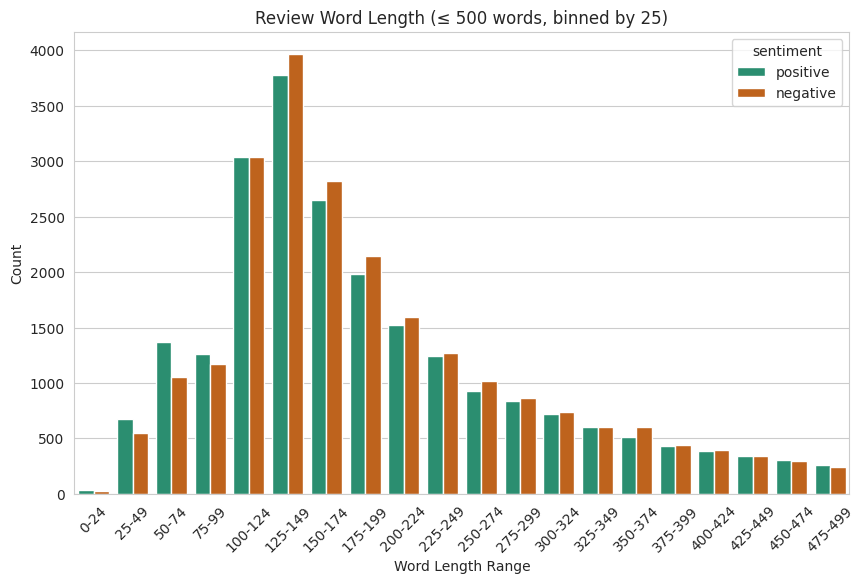

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure reviews are strings
df['review'] = df['review'].astype(str)

# Create a word length column (split by whitespace)
df['word_length'] = df['review'].str.split().str.len()

# Filter to only reviews with 500 words or less
df_filtered = df[df['word_length'] <= 500]

# Define bins of size 25 up to 500
bins = np.arange(0, 525, 25)  # 0, 25, 50, ..., 500
labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]

# Assign bins
df_filtered['word_bin'] = pd.cut(df_filtered['word_length'], bins=bins, labels=labels, include_lowest=True)

# Plot counts by bin and sentiment
sns.countplot(x='word_bin', hue='sentiment', data=df_filtered, palette="Dark2")
plt.title("Review Word Length (≤ 500 words, binned by 25)")
plt.xlabel("Word Length Range")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


I am seeing some interesting things here. The extremely short reviews are positive and then it flips to negative as the short reviews get a little longer.

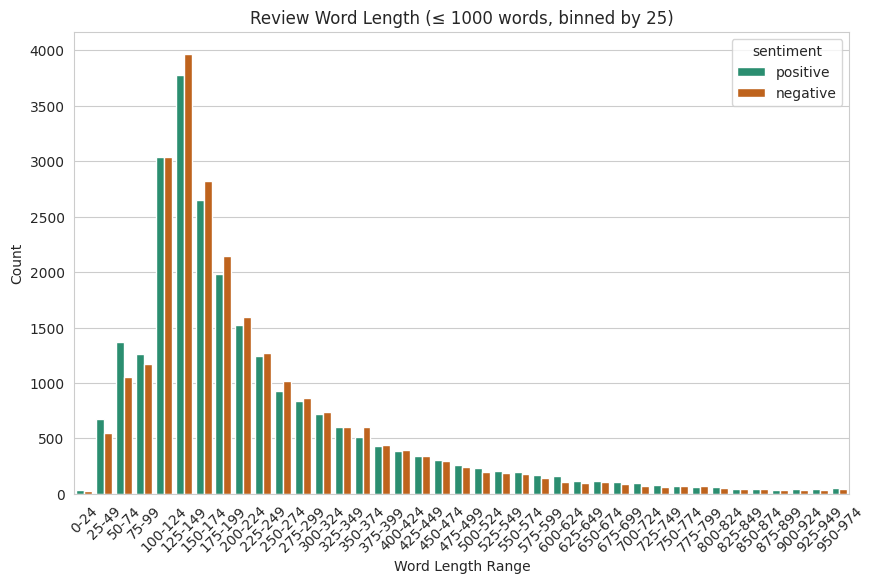

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure reviews are strings
df['review'] = df['review'].astype(str)

# Create a word length column (split by whitespace)
df['word_length'] = df['review'].str.split().str.len()

# Filter to only reviews with 1000 words or less
df_filtered = df[df['word_length'] <= 1000]

# Define bins of size 25 up to 1000
bins = np.arange(0, 1000, 25)  # 0, 25, 50, ..., 1000
labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]

# Assign bins
df_filtered['word_bin'] = pd.cut(df_filtered['word_length'], bins=bins, labels=labels, include_lowest=True)

# Plot counts by bin and sentiment
sns.countplot(x='word_bin', hue='sentiment', data=df_filtered, palette="Dark2")
plt.title("Review Word Length (≤ 1000 words, binned by 25)")
plt.xlabel("Word Length Range")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


I see some more interesting things.  It appears that as the reviews become extremely long, that the sentiment becomes positive. So, it looks like there are three buckets where the shortest reviews are dominated by positive sentiment, the mid length reviews are dominated by negative sentiment and the longer reviews appear to flip positive. Now I wannt to look at the extremely long reviews and roll up the graph again.

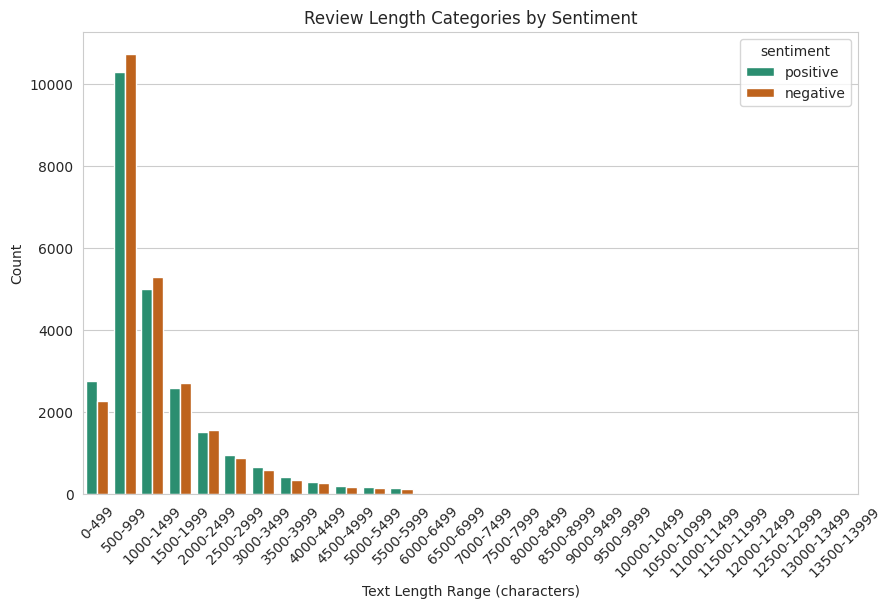

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def safe_binning(df, col='text_length', step=500):
    """
    Automatically creates bins from 0 up to the max length in the dataset.
    Ensures no samples are dropped.

    Parameters:
    df  : DataFrame containing the column
    col : Column name to bin (default 'text_length')
    step: Bin width (default 500 characters)
    """
    max_len = df[col].max()

    # Create bins from 0 to max length, with step size
    bins = np.arange(0, max_len + step, step)
    labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]

    df['length_bin'] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)
    return df

# Example usage:
df['review'] = df['review'].astype(str)
df['text_length'] = df['review'].str.len()

df = safe_binning(df, col='text_length', step=500)

sns.countplot(x='length_bin', hue='sentiment', data=df, palette="Dark2")
plt.title("Review Length Categories by Sentiment")
plt.xlabel("Text Length Range (characters)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


This graph shows me that there are a few highly enthusiastic and verbose people leaving reviews.  The majority of comments are between the 500 and 999 word count. The reviews that are super lengthy are too few in number to really be meaningful in predicting anything and simply serve to increase the average value.  The negative reviews are dominant at the mid to longer lengths but the positive reviews take the advantage as the reviews get longer.

In [ ]:
# Checking to make sure I have all data included after binning
print("Original rows:", len(df))   # total rows
print("Rows with NaN in length_bin:", df['length_bin'].isna().sum())
print("Rows kept after binning:", df['length_bin'].notna().sum())


Original rows: 50000
Rows with NaN in length_bin: 0
Rows kept after binning: 50000


In [ ]:
# Make sure text_length column exists
df['review'] = df['review'].astype(str)
df['text_length'] = df['review'].str.len()

# Print the average text length
print("Average text length:", round(df['text_length'].mean()))


Average text length: 1308


### 📊 Interpretation: Text Length

*Write your observations here:*
- What's the average text length?  

1308 would be the typical baseline review size for this dataset.
- Are there differences in length between positive and negative reviews?

Yes. The very short reviews (up to ~124 words) are lead by positive sentiment. In the mid-range (roughly 125-2000 words), negative reviews tend to be longer and more detailed expressing dissatisfaction.  At the extremely high end (2000+ words), the positive reviews reapper more frequently and could suggest that the highly enthusiastic reviewers can't stop writing. Overall, the shorter and longer reviews lean posistive while the medium length reviews lean negative.
- Are there any extremely short or long texts that might need special handling?


Extremely short reviews may not be meaningful such as one word responses such as "good" or "bad". Do they really provide enough context for sentiment classification?  The extremely long reviews with thousands of words could also introduce outliers that will skew the model. Both the extremely long and short reviews can be considered edge cases (or "extreme values" in old-school statistical terms).  Handling them separately can ensure the model focuses on the majority of the reviews and avoid bias from the extremes.

In [ ]:
# Display 5 sample reviews from each sentiment class
# YOUR CODE HERE
# Display 5 random positive reviews
print("Positive Reviews:\n")
print(df[df['sentiment'] == 'positive']['review'].sample(5, random_state=42).to_string(index=False))

# Display 5 random negative reviews
print("\nNegative Reviews:\n")
print(df[df['sentiment'] == 'negative']['review'].sample(5, random_state=42).to_string(index=False))

# Hint: Use df[df['sentiment'] == 'positive'].sample(5)
# Display examples from each class to get a feel for the data

Positive Reviews:

I don't know how or why this film has a meager ...
For a long time it seemed like all the good Can...
Terry Gilliam's and David Peoples' teamed up to...
What is there to say about an anti-establishmen...
This movie was made only 48 years after the end...

Negative Reviews:

I was looking forward to seeing Bruce Willis in...
Bugs Bunny accidentally ends up at the South Po...
I find it difficult to comprehend what makes vi...
It's been said several times - not least by me ...
New rule. Nobody is allowed to make any more Zo...


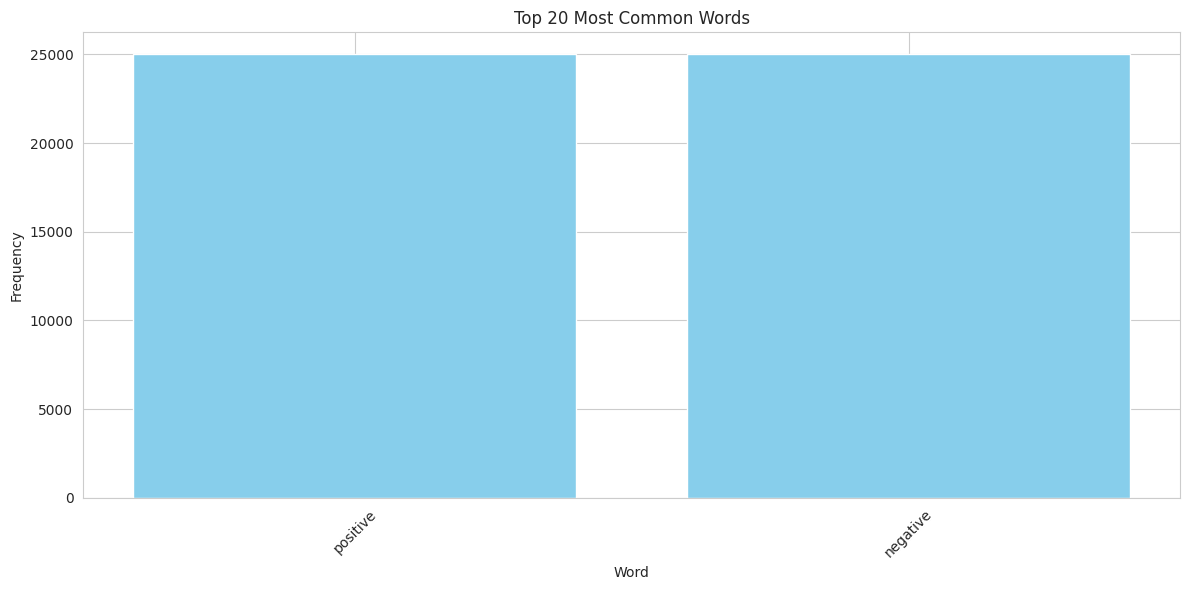

In [ ]:
# Analyze common words (optional but recommended)
# YOUR CODE HERE

from collections import Counter
import matplotlib.pyplot as plt

# Combine all text into one string, lowercase, and split into words
all_words = ' '.join(df['sentiment']).lower().split()

# Count most common words
common_words = Counter(all_words).most_common(20)

# Convert to DataFrame for plotting
words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Plot bar chart
plt.figure(figsize=(12,6))
plt.bar(words_df['Word'], words_df['Frequency'], color='skyblue')
plt.title('Top 20 Most Common Words')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




# Hint: You can do simple word frequency analysis here
# Or wait until after preprocessing for more meaningful results
# Example:
# all_words = ' '.join(df['text_column']).lower().split()
# common_words = Counter(all_words).most_common(20)
# Plot a bar chart of most common words

### 📝 EDA Summary

*Summarize your key findings from the EDA:*

1. **Dataset characteristics**:
There are 50,000 data set entries without any missing values.
Average length of the review is 1308 characters.
Word counts range from one word reviews to thousands of words dissertations.
2. **Data quality issues**: The length of the response being too short or too long are problematic. If they are too short, they might not really provide much meaning and if they are too long they could skew the averages or grind processing speed down.
3. **Key patterns observed**: Positive reviews are dominant in the very short reviews and in the very long reviews.  
Negative reviews dominate in the medium length reviews.
4. **Potential challenges**: The edge cases of very short and very long reviews might need special handling. The long reviews can grind down processing speed and require more resources to process.

---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [ ]:
# Import preprocessing libraries
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# For stopwords
# Option 1: Use sklearn's built-in stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Option 2: Use NLTK (uncomment if you prefer)
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))

print("✅ Preprocessing libraries imported!")

✅ Preprocessing libraries imported!


In [ ]:
# Create a text preprocessing function
import re
import string

def preprocess_text(text):
    """
    Clean and preprocess text data.

    Args:
        text (str): Raw text string

    Returns:
        str: Cleaned text string
    """
    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text



    # YOUR CODE HERE



    # Hint: Steps to implement:
    # 1. Convert to lowercase: text = text.lower()
    # 2. Remove URLs: text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove mentions and hashtags: text = re.sub(r'@\w+|#\w+', '', text)
    # 4. Remove punctuation: text = text.translate(str.maketrans('', '', string.punctuation))
    # 5. Remove numbers: text = re.sub(r'\d+', '', text)
    # 6. Remove extra whitespace: text = ' '.join(text.split())

    return text

# Test your function on a sample text
sample_text = "This is a TEST!!! Check out https://example.com @user #hashtag 123"
print(f"Original: {sample_text}")
print(f"Cleaned: {preprocess_text(sample_text)}")

# Apply the function to my Data Frame column
# Replace 'review' with actual column name in my dataset
df['cleaned_text'] = df['review'].apply(preprocess_text)

# 4. Verify by showing a few examples
print(df[['review', 'cleaned_text']].head())


Original: This is a TEST!!! Check out https://example.com @user #hashtag 123
Cleaned: this is a test check out
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        cleaned_text  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production br br the filmin...  
2  i thought this was a wonderful way to spend ti...  
3  basically theres a family where a little boy j...  
4  petter matteis love in the time of money is a ...  


In [ ]:
# Apply preprocessing to your dataset
# YOUR CODE HERE


# Apply preprocessing to dataset
df['cleaned_text'] = df['review'].apply(preprocess_text)


# Hint:
# df['cleaned_text'] = df['text_column'].apply(preprocess_text)



# Display some examples to verify the cleaning worked
print("Original vs Cleaned Examples:\n")
for i in range(5):  # show 5 random samples
    original = df['review'].iloc[i]
    cleaned = df['cleaned_text'].iloc[i]
    print(f"Original: {original}")
    print(f"Cleaned : {cleaned}\n")



print("✅ Text preprocessing complete!")

Original vs Cleaned Examples:

Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the 

In [ ]:
# Prepare your features (X) and target (y)
# YOUR CODE HERE
X = df['cleaned_text']  # preprocessed text column
y = df['sentiment']     # target variable

# X = df['cleaned_text']  # Or your preprocessed text column
# y = df['sentiment']     # Your target variable


# Check the shape
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (50000,)
Target shape: (50000,)


In [ ]:
# Split data into training and testing sets
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(
     X, y,
     test_size=0.2,      # 80% train, 20% test
     random_state=42,    # For reproducibility
     stratify=y          # Maintain class distribution
 )



# Hint:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,      # 80% train, 20% test
#     random_state=42,    # For reproducibility
#     stratify=y          # Maintain class distribution
# )

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 40000
Testing samples: 10000


In [ ]:
# Create TF-IDF features (Term Frequency - Inverse Document Frequency)
# YOUR CODE HERE
tfidf = TfidfVectorizer(
     max_features=5000,        # 🎯 IMPORTANT: Limit features to save memory!
     min_df=2,                 # Ignore terms that appear in fewer than 2 documents
     max_df=0.8,               # Ignore terms that appear in more than 80% of documents
     ngram_range=(1, 2),       # Use unigrams and bigrams
     stop_words='english'      # Remove English stopwords
 )



# Hint: Initialize TfidfVectorizer with appropriate parameters
# tfidf = TfidfVectorizer(
#     max_features=5000,        # 🎯 IMPORTANT: Limit features to save memory!
#     min_df=2,                 # Ignore terms that appear in fewer than 2 documents
#     max_df=0.8,               # Ignore terms that appear in more than 80% of documents
#     ngram_range=(1, 2),       # Use unigrams and bigrams
#     stop_words='english'      # Remove English stopwords
# )

# Fit on training data and transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape (train): (40000, 5000)
TF-IDF matrix shape (test): (10000, 5000)
Number of features: 5000


In [ ]:
# Explore the TF-IDF features (optional)
# YOUR CODE HERE
feature_names = tfidf.get_feature_names_out()
print("Sample features:", feature_names[:20])

# Hint: Look at the most important features
# feature_names = tfidf.get_feature_names_out()
# print("Sample features:", feature_names[:20])

Sample features: ['abandoned' 'abc' 'abilities' 'ability' 'able' 'absence' 'absolute'
 'absolutely' 'absurd' 'abuse' 'abysmal' 'academy' 'academy award'
 'accent' 'accents' 'accept' 'acceptable' 'accepted' 'accident'
 'accidentally']


### 📝 Preprocessing Summary

*Document your preprocessing choices:*

1. **Preprocessing steps applied**:

 - Converted all text to lowercase for consistency

 - Removed URLs, mentions and hashtags

 - Removed punctuation and numerical characters

 - Removed extra whitespace

 - Verified cleaning with sample outputs


2. **TF-IDF parameters chosen**:

 - Maximum features = 5000.  This limit is to save memory.
 - Ignore words that appear in less than 2 documents
 - Exclude words that appear in more than 80% of the documents
 - Include unigrams and bigrams
 - Removed English stop words


3. **Final feature count**:

 - After fitting, the features were capped at 5,000.  
  - It was trained and tested on 5,000 features and then verified with {len(tfidf.get_feature_names_out())}") which returned the same value of 5,000.


4. **Rationale for choices**:

 - Converting text to lowercase, removing punctuation, numbers and whitespace creates standardized input.

 - Removing URLs, mentions and hashtags because they are not relevant to sentiment and force the model to train on meaningful words.

 - Removed stopwords to improve efficiency

 - Limiting the features to 5,000 saves on memory.

 - Included bigrams to capture critical sentiment phrases like "not happy" or "very good".


---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [ ]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

import time
from datetime import timedelta

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 1: Logistic Regression

In [ ]:
# Train Logistic Regression model
# YOUR CODE HERE

#Logistic Regression
print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
     max_iter=1000,           # Increase if model doesn't converge - make sure you have enough iterations to converge.
     random_state=42,         # Fixes random start point for reproducibility, 42 is HT to Hitchhiker's Guide to the Galaxy
     n_jobs=-1                # Use all CPU cores
  )

lr_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")


# Hint:
# print("Training Logistic Regression...")
# start_time = time.time()

# lr_model = LogisticRegression(
#     max_iter=1000,           # Increase if model doesn't converge
#     random_state=42,         # Fixes random start point for reproducibility, 42 is HT to Hitchhiker's Guide to the Galaxy
#     n_jobs=-1                # Use all CPU cores
# )

# lr_model.fit(X_train_tfidf, y_train)

# training_time = time.time() - start_time
# print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Logistic Regression...
✅ Training complete in 0:00:02


In [ ]:
# Make predictions with Logistic Regression
# YOUR CODE HERE

y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_lr.shape}")


# y_pred_lr = lr_model.predict(X_test_tfidf)
# print(f"Predictions shape: {y_pred_lr.shape}")

Predictions shape: (10000,)


## Model 2: Multinomial Naive Bayes

In [ ]:
# Train Naive Bayes model
# YOUR CODE HERE

# Train Multinomial Naive Bayes and count the training time
print("Training Multinomial Naive Bayes...")
start_time = time.time()


nb_model = MultinomialNB()      # Using default parameters: alpha=1.0, fit-prior-True,  class_prior-None, force_alpha='warn'
nb_model.fit(X_train_tfidf, y_train)
nb_time = time.time() - start_time


training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")




# Hint:
# print("Training Multinomial Naive Bayes...")
# start_time = time.time()

# nb_model = MultinomialNB()
# nb_model.fit(X_train_tfidf, y_train)

# training_time = time.time() - start_time
# print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Multinomial Naive Bayes...
✅ Training complete in 0:00:00


In [ ]:
# Make predictions with Naive Bayes
# YOUR CODE HERE

# Multinomial Naive Bayes Prediction
y_pred_nb = nb_model.predict(X_test_tfidf)
print("Multinomial Naive Bayes Performance:")
print(classification_report(y_test, y_pred_nb))
print(f"Training time: {nb_time:.2f} seconds")


# y_pred_nb = nb_model.predict(X_test_tfidf)

Multinomial Naive Bayes Performance:
              precision    recall  f1-score   support

    negative       0.87      0.84      0.85      5000
    positive       0.84      0.87      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

Training time: 0.11 seconds


## Model 3 (Optional): Additional Model

*Train a third model if you'd like to explore further!*

In [ ]:
# Train your third model (optional)
# YOUR CODE HERE

# Example: Random Forest
print("Training Random Forest...")
start_time = time.time()

rf_model = RandomForestClassifier(
     n_estimators=100,        # Number of trees
     max_depth=20,            # Limit depth to save memory
     random_state=42,         # Fix  randeom start for reproducibilty
     n_jobs=-1                # Use all CPU cores
 )

rf_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

y_pred_rf = rf_model.predict(X_test_tfidf)



# Example: Random Forest
# print("Training Random Forest...")
# start_time = time.time()

# rf_model = RandomForestClassifier(
#     n_estimators=100,        # Number of trees
#     max_depth=20,            # Limit depth to save memory
#     random_state=42,
#     n_jobs=-1                # Use all CPU cores
# )

# rf_model.fit(X_train_tfidf, y_train)

# training_time = time.time() - start_time
# print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

# y_pred_rf = rf_model.predict(X_test_tfidf)

Training Random Forest...
✅ Training complete in 0:00:18


### 📝 Model Training Summary

*Document your models:*

| Model | Training Time | Parameters | Notes |
|-------|--------------|------------|-------|
| Logistic Regression | 00:00:02| max iterations =1000, random state = 42, use all available computer cores wit n_jobs-1|Fast|
| Naive Bayes |00:00:00 |default parameters: alpha=1.0, fit-prior-True,  class_prior-None, force_alpha='warn' |Good for text data |
| Random Forest Model 3 |0:00:23 |number of trees=100, max depth=20, random state=42, use all available computer cores |Slower, ensemble |

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [ ]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import seaborn as sns
import matplotlib.pyplot as plt


print("✅ Evaluation metrics imported!")

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [ ]:
# Calculate metrics for Logistic Regression
# YOUR CODE HERE

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

# Calculate the metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='weighted')
recall = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

# Print Metrics
print(f"Accuracy:  {accuracy:.4f}")  # How many classified correctly
print(f"Precision: {precision:.4f}") # How many predicted correctly
print(f"Recall:    {recall:.4f}")    # How many positive reviews identified correctly
print(f"F1-Score:  {f1:.4f}")        # The balance between precision and recall
print("\n")

# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))






# Hint:
# print("=" * 50)
# print("LOGISTIC REGRESSION RESULTS")
# print("=" * 50)

# accuracy = accuracy_score(y_test, y_pred_lr)
# precision = precision_score(y_test, y_pred_lr, average='weighted')
# recall = recall_score(y_test, y_pred_lr, average='weighted')
# f1 = f1_score(y_test, y_pred_lr, average='weighted')

# print(f"Accuracy:  {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall:    {recall:.4f}")
# print(f"F1-Score:  {f1:.4f}")
# print("\n")

# print("Classification Report:")
# print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.8889
Precision: 0.8890
Recall:    0.8889
F1-Score:  0.8889


Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



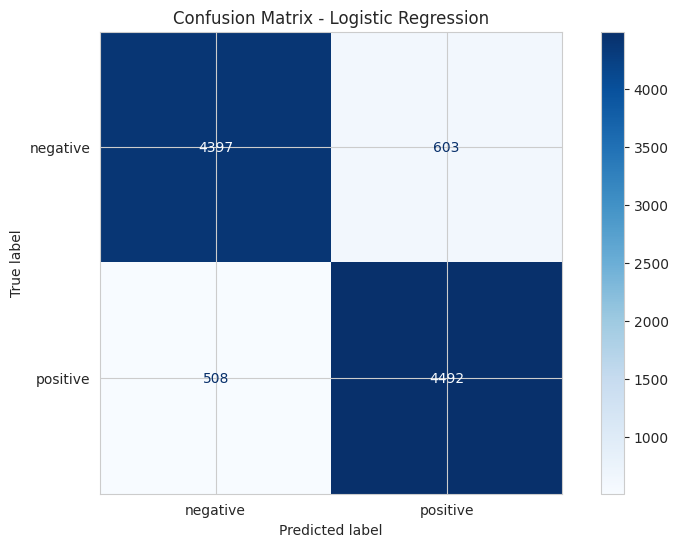

In [ ]:
# Plot confusion matrix for Logistic Regression
# YOUR CODE HERE

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()





# Hint:
# cm = confusion_matrix(y_test, y_pred_lr)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
# disp.plot(cmap='Blues', values_format='d')
# plt.title('Confusion Matrix - Logistic Regression')
# plt.show()

### 📊 Interpretation: Logistic Regression

*Analyze the results:*

1. **Overall performance**:

 - Accuracy:  0.8889

 - Precision: 0.8890

 - Recall:    0.8889

 - F1-Score:  0.8889

 - This model is fairly consistent acrosst the metrics, and across the positive and negative classes.  

2. **Strengths**: This model is fairly consistent across the metrics
3. **Weaknesses**: Slightly lower recall for negatives.
4. **Confusion matrix insights**:

 - True positives and true negatives are high meaning balanced classification.  
 - There are some misclassifications where the negative reviews are labeled as positive and where some positive reveiews are labeled as negative. The misclassifications are fairly close.  
  - The model is fairly good at sentiment, but probably has issues with more nuanced speech like sarcasm or feedback sandwiches where there is both positive and negative text.

## Evaluate Model 2: Naive Bayes

In [ ]:
# Calculate metrics for Naive Bayes
# YOUR CODE HERE

print("=" * 50)
print("NAIVE BAYE RESULTS")
print("=" * 50)

# Calculate the metrics
accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb, average='weighted')
recall = recall_score(y_test, y_pred_nb, average='weighted')
f1 = f1_score(y_test, y_pred_nb, average='weighted')

# Print Metrics
print(f"Accuracy:  {accuracy:.4f}")  # How many classified correctly
print(f"Precision: {precision:.4f}") # How many predicted correctly
print(f"Recall:    {recall:.4f}")    # How many positive reviews identified correctly
print(f"F1-Score:  {f1:.4f}")        # The balance between precision and recall
print("\n")

# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_nb))





# Follow the same pattern as above

NAIVE BAYE RESULTS
Accuracy:  0.8564
Precision: 0.8568
Recall:    0.8564
F1-Score:  0.8564


Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.84      0.85      5000
    positive       0.84      0.87      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



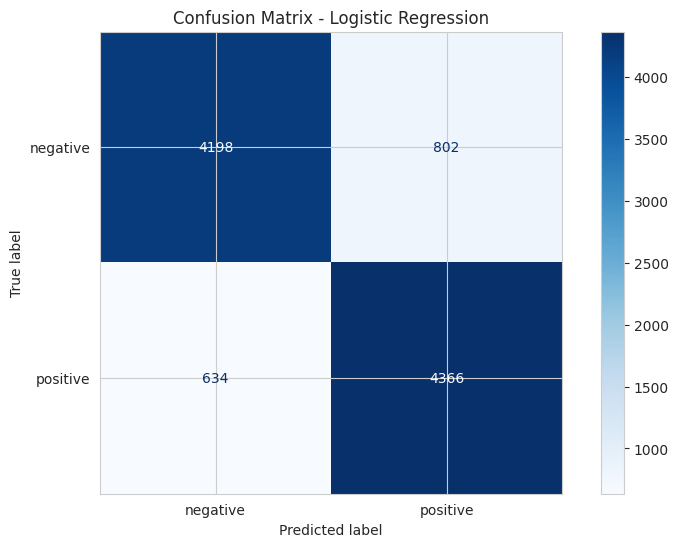

In [ ]:
# Plot confusion matrix for Naive Bayes
# YOUR CODE HERE

#Predictions from Naive Bayes
y_pred_nb = nb_model.predict(X_test_tfidf)


# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_nb)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()






# Hint:
# cm = confusion_matrix(y_test, y_pred_lr)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
# disp.plot(cmap='Blues', values_format='d')
# plt.title('Confusion Matrix - Logistic Regression')
# plt.show()


### 📊 Interpretation: Naive Bayes

*Analyze the results:*

1. **Overall performance**:

 - Accuracy:  0.8564

 - Precision: 0.8568

 - Recall:    0.8564

 - F1-Score:  0.8564

 - This model is fairly consistent acrosst the metrics, and across the positive and negative classes.

2. **Strengths**:

 - NB trained super fast taking 0 seconds. With larger data sets, the NB model is ideal.

 - NB is designed for text classification.

 - Both the positive and negative classes score F1 closely which does not indicate a strong bias


3. **Weaknesses**:

 - Slightly lower recall for negatives.
 - The model itself has inherent weakness as it assumes independence between words which means it will likely miss sarcasm and negations.

4. **Confusion matrix insights**:

 - False negatives and false positives are higher but, the distribution is balancd.
 - Mistakes among classes does not indicate strong bias towards one class or the other.




## Evaluate Model 3 (Optional)

In [ ]:
# Calculate metrics for your third model (if applicable)
# YOUR CODE HERE


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

# Print metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\n")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))


RANDOM FOREST RESULTS
Accuracy:  0.8268
Precision: 0.8306
Recall:    0.8268
F1-Score:  0.8263


Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.77      0.82      5000
    positive       0.80      0.88      0.84      5000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



Interpretation: Random Forest

Analyze the results:

Overall performance:
Accuracy: 0.8268

Precision: 0.8306

Recall: 0.8268

F1-Score: 0.8263


Strengths:

This model is fairly consistent acrosst the metrics, and across the positive and negative classes.

Precision and recall are very close meaning the model is not overly biased toward either minimiizing false positives or false negatives.


Weaknesses:

Accuracy of ~83% is terrible in comparison to the other two models.

Random Forests are harder to interpret.

Compared to the other two models, this is a super slow model. Though 23 seconds for a Random Forest model is fast, it is only because the data set was small and of little complexity. If the training set were large or complex, the Random Forest calculation will become extremely computationally heavy.



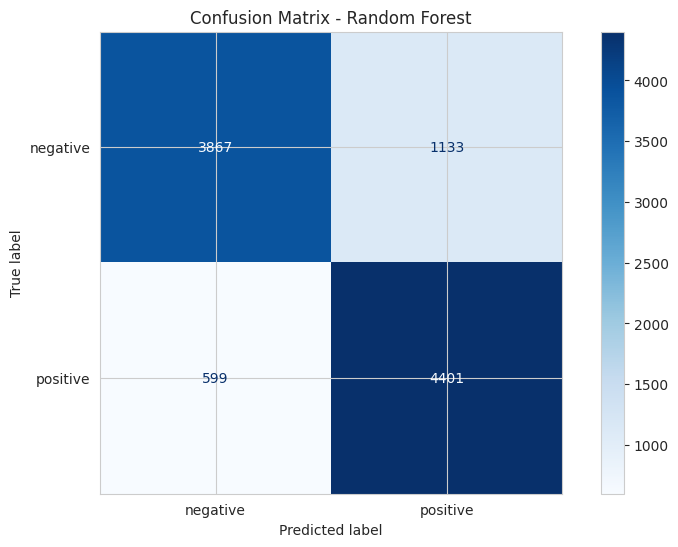

In [ ]:
# Plot confusion matrix for your third model (if applicable)
# YOUR CODE HERE


from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions from Random Forest
y_pred_rf = rf_model.predict(X_test_tfidf)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)






disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest')
plt.show()

## Model Comparison

In [ ]:
# Create a comparison table of all models
# YOUR CODE HERE

import pandas as pd

# Logistic Regression metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted')
rec_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')


# Naive Bayes metrics
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted')
rec_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')



# Random Forest metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')


# Create comparison tabler
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [acc_lr, acc_nb, acc_rf],
    'Precision': [prec_lr, prec_nb, prec_rf],
    'Recall': [rec_lr, rec_nb, rec_rf],
    'F1-Score': [f1_lr, f1_nb, f1_rf]
})

display(results)






# Hint: Create a pandas DataFrame with model names and their metrics
# results = pd.DataFrame({
#     'Model': ['Logistic Regression', 'Naive Bayes'],
#     'Accuracy': [acc_lr, acc_nb],
#     'Precision': [prec_lr, prec_nb],
#     'Recall': [rec_lr, rec_nb],
#     'F1-Score': [f1_lr, f1_nb]
# })
# display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8889,0.889040,0.8889,0.888890
1,Naive Bayes,0.8564,0.856803,0.8564,0.856359
2,Random Forest,0.8268,0.830571,0.8268,0.826305


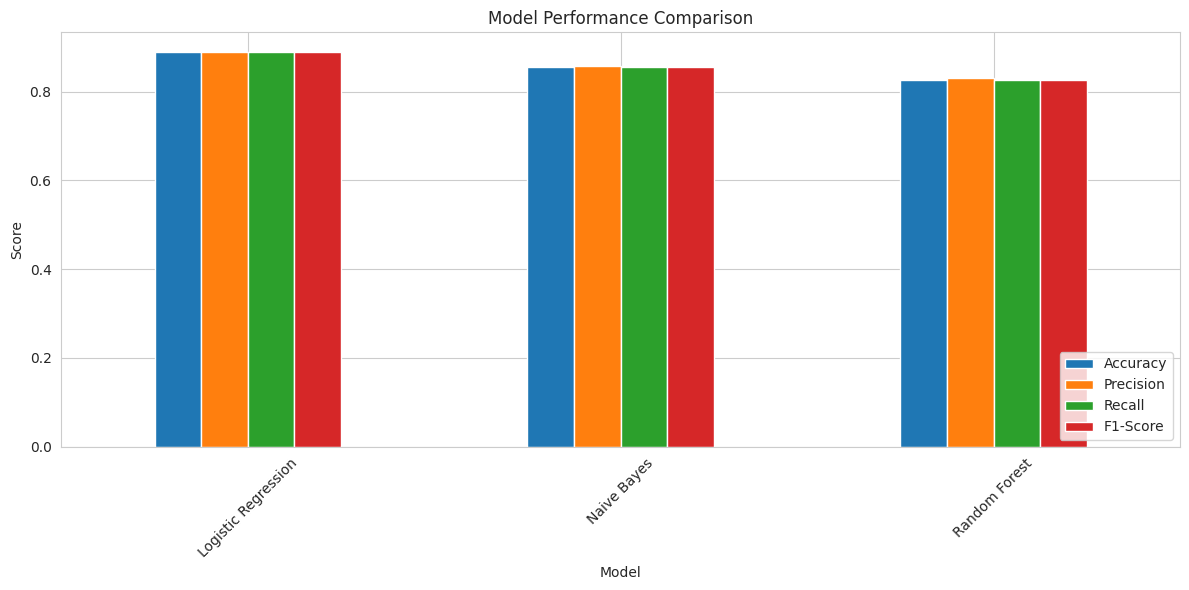

In [ ]:
# Visualize model comparison
# YOUR CODE HERE

import matplotlib.pyplot as plt

# Assuming you already created the 'results' DataFrame with metrics
results.set_index('Model').plot(kind='bar', figsize=(12, 6))

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()






# Hint: Create a bar plot comparing metrics across models
# results.set_index('Model').plot(kind='bar', figsize=(12, 6))
# plt.title('Model Performance Comparison')
# plt.ylabel('Score')
# plt.xticks(rotation=45)
# plt.legend(loc='lower right')
# plt.tight_layout()
# plt.show()

### 📊 Model Comparison Analysis

*Compare and contrast your models:*

1. **Which model performed best?**:

 - Logistic Regression had the highest scores of all the metrics.

2. **What metrics did you prioritize and why?**:
 - F1 score because it balance precision and recall.

3. **Trade-offs between models**:
Logistic regression
 - best balance of accuracy, precision, recall and F1
 - slower

 Naive Bayes
  - faster
  - lower recall for negatives
  - overall performance lower than logistic regression

Random Forest
 - can capture non-linear relationships
 - Much lower performance
 - More compute intensive

4. **Which model would you recommend for deployment?**
 - Logistic regression because it performed best across all metrics and was fast enough and didn't overly use compute power.



## Error Analysis (Optional but Recommended)

In [ ]:
# Analyze misclassified examples
# YOUR CODE HERE

misclassified_indices = np.where(y_pred_lr != y_test)[0]
print(f"Number of misclassified examples: {len(misclassified_indices)}")

# Display some misclassified examples
for idx in misclassified_indices[:5]:
     print(f"\nText: {X_test.iloc[idx]}")
     print(f"True label: {y_test.iloc[idx]}")
     print(f"Predicted label: {y_pred_lr[idx]}")
     print("-" * 80)





# Hint: Find examples where the model was wrong
# misclassified_indices = np.where(y_pred_lr != y_test)[0]
# print(f"Number of misclassified examples: {len(misclassified_indices)}")

# Display some misclassified examples
# for idx in misclassified_indices[:5]:
#     print(f"\nText: {X_test.iloc[idx]}")
#     print(f"True label: {y_test.iloc[idx]}")
#     print(f"Predicted label: {y_pred_lr[idx]}")
#     print("-" * 80)

Number of misclassified examples: 1111

Text: the story of the bride fair is an amusing and engaging one and it is to the filmmakers credit that he sets out to portray rural minnesotans with the same respect ordinarily reserved for coastdwellers it is weird though to find an independent movie the brainchild of a single person that is as unambitious and clichéridden as a committeebrewed hollywood potboilerbr br the portrait of rural people is intended to be affectionate i think but these characters dont ring true to mei have had quite a few meals in smalltown diners but never overheard a debate on the merits of different nineteenthcentury english novelists one might suggest that writerdirector semans has no more experience with rural culture than the coen brothers and considerably less satiric verve
True label: negative
Predicted label: positive
--------------------------------------------------------------------------------

Text: this movie is really wack there is really nothing nice 

### 📊 Error Analysis Insights

*What patterns do you notice in the errors?*

1. **Common types of errors**:

 - nuanced reviews.
 - irony or sarcasm.
 - slang words
 - run on sentences/descriptions that add a lot of detail
  - bag of words/TF-IDF limitations

3. **How could you improve the model?**:

 - add explicit rules to detect negation like "not good"
- add slang words
 - add the misclassified samples back into training set to improve robustness
  - add BERT to capture meaning and not just words.

---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings

- Provide actionable business recommendations

- Discuss limitations and future improvements

- Reflect on what you learned



---

## 📝 Executive Summary

*Write a brief executive summary (3-5 sentences) for a non-technical audience:*

This project looked at at 50,000 IMDB movie reviews to classify them as either positive or negative. 3 different models were tested - logistical regression, Naive Bayes and Random Forest - to determine which performed the best. Several statistical metrics are calculated to provide a way to compare apples to apples differences between the models.

## 🎯 Key Findings

*List your main discoveries:*

1. **Dataset insights**:

   - The data set contained labels as positive or negative.

   - All data was present, no null values.

   - Reviews varied wildly in length and complexity.

   - Sarcasm or mixed reviews challenged the models.

2. **Model performance**:

   - The logistic regression model was best in terms of performance across all metrics.

   - The Naive Bayes model came in second place but was super speedy in terms of processing.

   - The Random Forest was a resource hog and underperformed.

3. **Best model and why**:
   - Logistic regression is the best model because is balances accuracy, interpreabiliyt and is fairly light on computation resources.
4. **Surprising discoveries**:
   - Random Forest was not competitive! I thought it would perform better but it was the worst!

   - Naive Bayes did pretty good and was very similar to Logistic Regression.

## 💼 Business Recommendations

*How can these results be used in practice?*

1. **Immediate applications**:

   - Use Logistic Regression  for sentiment analysis.
   - Avoid using Random Forest because it is too complex and doesn't give better results - it actually gave worse results.  
   - Use Naive Bayes if you want to run a quick and dirty model or as a backup to Logistic Regression.  

2. **Who should use this model?**:

   - Streaming platforms
   
   - Studios and producers

   - Movie Critics

   
3. **How to interpret predictions**:
   - Predictions signal whether a review is positive or negative


4. **Warning signs to watch for**:
   - Misclassifications in nuanced, sarcastic or mixed-tone reviews
    - Long and complex reviews may need to have sentence level analysis

## ⚠️ Limitations

*Be honest about the limitations of your analysis:*

1. **Data limitations**:
The reviews are only from IMDB and may not represent broader audience sentiment
There are only two reviews: positive or negative.
There are no star ratings.
2. **Model limitations**:
Sarcasm and irony are difficult for the models.
TD - IDF ignores context and word order so it doesn't capture nuance.
In the future:

3. **Generalization concerns**:
   Models trained on IMDB data may not generalize or predict well for other domains.

4. **Resource constraints**:
   Larger datasets are more demanding for computational resources and time.

## 🚀 Future Improvements

*What would you do with more time/resources?*

1. **Data collection**:
   - Include other datasets such as Rotten tomatoes, Twitter or Facebook
2. **Feature engineering**:
   -Incorporate n-grams

3. **Advanced models**:
Use BERT and have the model look more at the sentiment or even sentence length sentiment.  
4. **Deployment considerations**:
   - create a live database platform that would show real time sentiment

## 🎓 Lessons Learned

*Reflect on your experience:*

1. **Technical skills gained**:
   - Getting more practice with python
   - Committing to memory what certain models do better than others   

2. **Challenges overcome**:
   - ChatGPT finds my typos in code and fixes it.
   - ChatGPT quickly points out where my code is deficient/wrong and why. I am still learning practical application of python. I am getting pretty good at vibe coding.

3. **What would you do differently?**:
   - I would vibe code all the visualizations and spend most of my time on analyzing the data instead of coding.


4. **Most valuable insight**:
   - Through these guided analysis, I am starting to see patterns of what to do take root in terms of coding and what to look for in terms of output.  I am more relaxed and not as intimidated by the code since I can vibe code and theoretically can spend more time on analzying the data.  I am still so slow with charting and creating the visuals.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*